In [1]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [28]:
url='https://www.myntra.com/women-shirts-tops-tees?f=Categories%3AShirts'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
shirts = session.get(url,headers=headers,timeout=15)

print("done")
print(shirts.status_code)

starting
done
200


In [29]:
soup= BeautifulSoup(shirts.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Women Tops - Get 60, 000 + Tops &amp; Tees Online for Ladies | Myntra
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="ap
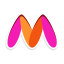

In [30]:
print(soup.prettify())

In [31]:
items= soup.find_all('li',class_='product-base')
print(len(items))

0


In [32]:
print("product-base" in shirts.text)

False


In [13]:
!pip install selenium

In [33]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/women-shirts-tops-tees?f=Categories%3AShirts"
driver.get(url)

time.sleep(10)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [34]:
print(items[0].prettify())

<li class="product-base" id="36189600">
 <div class="product-thumbShim">
 </div>
 <div class="product-ratingsContainer">
  <span>
   4.2
  </span>
  <span class="myntraweb-sprite product-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon">
  </span>
  <div class="product-ratingsCount">
   <div class="product-separator">
    |
   </div>
   <!-- react-text: 438 -->
   2k
   <!-- /react-text -->
  </div>
 </div>
 <a data-refreshpage="true" href="shirts/here%26now/herenow-women-oversized-fit-solid-spread-collar-cotton-casual-shirt/36189600/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(255, 237, 243);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_

In [35]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [36]:
print(title[:3])
print(price[:3])
print(image_urls[:3])

['Women Oversized Cotton Shirt', 'Cotton Relaxed Fit Shirt', 'Women Cotton Casual Shirt']
['Rs. 689Rs. 2299(Rs. 1610 OFF)', 'Rs. 894Rs. 2199(59% OFF)', 'Rs. 537Rs. 2800(81% OFF)']
['https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/AUGUST/18/6zT0pBpM_3fc2daa8c6e042a390768ea6628735d4.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/NOVEMBER/19/22UtRrDj_367808526f604fe98a52741c11ff1e69.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/JUNE/16/86uINalM_136e29c4f0ed4590ac93272efa373cd3.jpg']


In [37]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [38]:
df_shirts=pd.DataFrame(d)

In [39]:
df_shirts.head()

,title,brand,rating,price,size,rating_count,image_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2|2k,Rs. 689Rs. 2299(Rs. 1610 OFF),Sizes: M,|2k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Cotton Relaxed Fit Shirt,Roadster,4.2|1.8k,Rs. 894Rs. 2199(59% OFF),Sizes: XS,|1.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Casual Shirt,EKISHA,4.1|580,Rs. 537Rs. 2800(81% OFF),Sizes: XL,|580,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Slim Fit Casual Shirt,CORSICA,4.1|4.5k,Rs. 643Rs. 1899(66% OFF),Sizes: L,|4.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Casual Shirt,CORSICA,None,Rs. 599Rs. 1999(70% OFF),Sizes: M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [40]:
print(df_shirts.shape)

(50, 7)


In [41]:
df_shirts_copy= df_shirts.copy()

In [44]:
df_shirts.describe()

,title,brand,rating,price,size,rating_count,image_url
count,50,50,36,50,50,36,50
unique,31,23,35,45,6,33,50
top,Casual Shirt,Roadster,4.4|8k,Rs. 782Rs. 1899(59% OFF),Sizes: S,|1.1k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
freq,15,9,2,5,13,2,1


In [45]:
df_shirts["rating"] = df_shirts["rating"].str.split("|").str[0]

In [46]:
df_shirts.head()

,title,brand,rating,price,size,rating_count,image_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,Rs. 689Rs. 2299(Rs. 1610 OFF),Sizes: M,|2k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Cotton Relaxed Fit Shirt,Roadster,4.2,Rs. 894Rs. 2199(59% OFF),Sizes: XS,|1.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Casual Shirt,EKISHA,4.1,Rs. 537Rs. 2800(81% OFF),Sizes: XL,|580,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Slim Fit Casual Shirt,CORSICA,4.1,Rs. 643Rs. 1899(66% OFF),Sizes: L,|4.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Casual Shirt,CORSICA,None,Rs. 599Rs. 1999(70% OFF),Sizes: M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [47]:
df_shirts["rating_count"] = df_shirts["rating_count"].str.split("|").str[1]

In [48]:
df_shirts.head()

,title,brand,rating,price,size,rating_count,image_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,Rs. 689Rs. 2299(Rs. 1610 OFF),Sizes: M,2k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Cotton Relaxed Fit Shirt,Roadster,4.2,Rs. 894Rs. 2199(59% OFF),Sizes: XS,1.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Casual Shirt,EKISHA,4.1,Rs. 537Rs. 2800(81% OFF),Sizes: XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Slim Fit Casual Shirt,CORSICA,4.1,Rs. 643Rs. 1899(66% OFF),Sizes: L,4.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Casual Shirt,CORSICA,None,Rs. 599Rs. 1999(70% OFF),Sizes: M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [49]:
df_shirts["size"] = df_shirts["size"].str.split(":").str[1]
df_shirts["current_price"] = (
    df_shirts["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)
df_shirts["original_price"] = (
    df_shirts["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)
df_shirts["discount"] = (
    df_shirts["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)
df_shirts["category"]= 'shirts'

In [50]:
df_shirts.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,Rs. 689Rs. 2299(Rs. 1610 OFF),M,2k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299,Rs. 1610 OFF,shirts
1,Cotton Relaxed Fit Shirt,Roadster,4.2,Rs. 894Rs. 2199(59% OFF),XS,1.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199,59% OFF,shirts
2,Women Cotton Casual Shirt,EKISHA,4.1,Rs. 537Rs. 2800(81% OFF),XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800,81% OFF,shirts
3,Slim Fit Casual Shirt,CORSICA,4.1,Rs. 643Rs. 1899(66% OFF),L,4.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899,66% OFF,shirts
4,Casual Shirt,CORSICA,None,Rs. 599Rs. 1999(70% OFF),M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999,70% OFF,shirts


In [51]:
df_shirts.drop(columns=["price"], inplace=True)

In [52]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [53]:
df_shirts['product_url']= product_url

In [54]:
df_shirts['product_url']

0     https://www.myntra.com/shirts/here%26now/heren...
1     https://www.myntra.com/shirts/roadster/the-roa...
2     https://www.myntra.com/shirts/ekisha/ekisha-wo...
3     https://www.myntra.com/shirts/corsica/corsica-...
4     https://www.myntra.com/shirts/corsica/corsica-...
5     https://www.myntra.com/shirts/hancock/hancock-...
6     https://www.myntra.com/shirts/sixth+house/sixt...
7     https://www.myntra.com/shirts/roadster/the-roa...
8     https://www.myntra.com/shirts/tokyo+talkies/to...
9     https://www.myntra.com/shirts/aahwan/aahwan-wo...
10    https://www.myntra.com/shirts/molly+%26+michel...
11    https://www.myntra.com/shirts/tokyo+talkies/to...
12    https://www.myntra.com/shirts/all+about+you/al...
13    https://www.myntra.com/shirts/roadster/the-roa...
14    https://www.myntra.com/shirts/urbano+fashion/u...
15    https://www.myntra.com/shirts/roadster/the-roa...
16    https://www.myntra.com/shirts/molly+%26+michel...
17    https://www.myntra.com/shirts/styli/styli-

In [55]:
df_shirts.sample(3)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
21,Opaque Formal Shirt,Style Quotient,4.3,XL,1.1k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",515,1199,57% OFF,shirts,https://www.myntra.com/shirts/style+quotient/s...
45,Opaque Casual Shirt,KALAMIR,4.1,XS,93,"https://assets.myntassets.com/dpr_2,q_60,w_210...",925,2999,69% OFF,shirts,https://www.myntra.com/shirts/kalamir/kalamir-...
18,Solid Regular Fit Shirt,Roadster,4.4,XS,8k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",778,1899,Rs. 1121 OFF,shirts,https://www.myntra.com/shirts/roadster/the-roa...


In [56]:
df_shirts.isnull().sum()

title              0
brand              0
rating            14
size               0
rating_count      14
image_url          0
current_price      0
original_price     1
discount           1
category           0
product_url        0
dtype: int64

In [57]:
df_shirts_copy=df_shirts.copy()

In [59]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_shirts["rating_count"] = df_shirts["rating_count"].apply(convert_count)

In [60]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299,Rs. 1610 OFF,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199,59% OFF,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800,81% OFF,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899,66% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,None,M,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999,70% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...


In [61]:
df_shirts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          36 non-null     object 
 3   size            50 non-null     object 
 4   rating_count    36 non-null     float64
 5   image_url       50 non-null     object 
 6   current_price   50 non-null     object 
 7   original_price  49 non-null     object 
 8   discount        49 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(1), object(10)
memory usage: 4.4+ KB


In [62]:
df_shirts["rating"] = pd.to_numeric(df_shirts["rating"], errors="coerce")
df_shirts["current_price"] = pd.to_numeric(df_shirts["current_price"], errors="coerce")
df_shirts["original_price"] = pd.to_numeric(df_shirts["original_price"], errors="coerce")

In [63]:
df_shirts["rating_count"] = df_shirts["rating_count"].fillna(0).astype(int)

In [64]:
df_shirts["original_price"] = (
    df_shirts["original_price"]
    .fillna(0)
    .astype(int)
)

In [65]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299,Rs. 1610 OFF,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199,59% OFF,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800,81% OFF,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899,66% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,NaN,M,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999,70% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...


In [66]:
df_shirts["discount"] = (
    df_shirts["discount"]
    .str.extract(r"(\d+)")
)
df_shirts["discount"] = pd.to_numeric(df_shirts["discount"], errors="coerce").fillna(0)
df_shirts["selling_price"] = (
    df_shirts["original_price"] * (1 - df_shirts["discount"] / 100)
)

In [67]:
df_shirts['current_price']= df_shirts['selling_price']

In [68]:
df_shirts= df_shirts.drop('selling_price',axis=1)

In [69]:
df_shirts['original_price']= df_shirts['original_price'].astype(float)

In [70]:
df_shirts

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",-34714.90,2299.0,1610.0,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",901.59,2199.0,59.0,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",532.00,2800.0,81.0,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",645.66,1899.0,66.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,NaN,M,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599.70,1999.0,70.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...
5,Slim Fit Cotton Formal Shirt,Hancock,4.4,M,869,"https://assets.myntassets.com/dpr_2,q_60,w_210...",854.55,1899.0,55.0,shirts,https://www.myntra.com/shirts/hancock/hancock-...
6,Casual Shirt,Sixth House,3.9,S,173,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399.75,1599.0,75.0,shirts,https://www.myntra.com/shirts/sixth+house/sixt...
7,Pure Cotton Casual Shirt,Roadster,4.3,XS,5700,"https://assets.myntassets.com/dpr_2,q_60,w_210...",-14015.65,1499.0,1035.0,shirts,https://www.myntra.com/shirts/roadster/the-roa...
8,Floral Printed Casual Shirt,Tokyo Talkies,4.2,S,403,"https://assets.myntassets.com/dpr_2,q_60,w_210...",136.37,1049.0,87.0,shirts,https://www.myntra.com/shirts/tokyo+talkies/to...
9,Slim Fit Casual Shirt,AAHWAN,3.7,L,1000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599.70,1999.0,70.0,shirts,https://www.myntra.com/shirts/aahwan/aahwan-wo...


In [82]:
df_shirts=df_shirts_copy.copy()

In [83]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299,Rs. 1610 OFF,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1.8k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199,59% OFF,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800,81% OFF,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4.5k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899,66% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,None,M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999,70% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...


In [84]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_shirts["rating_count"] = df_shirts["rating_count"].apply(convert_count)

In [85]:
df_shirts["rating"] = pd.to_numeric(df_shirts["rating"], errors="coerce")
df_shirts["current_price"] = pd.to_numeric(df_shirts["current_price"], errors="coerce")
df_shirts["original_price"] = pd.to_numeric(df_shirts["original_price"], errors="coerce")

In [86]:
df_shirts["rating_count"] = df_shirts["rating_count"].fillna(0).astype(int)

In [87]:
df_shirts["original_price"] = (
    df_shirts["original_price"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("₹", "")
)

df_shirts["original_price"] = pd.to_numeric(
    df_shirts["original_price"],
    errors="coerce"
)

In [88]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299.0,Rs. 1610 OFF,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199.0,59% OFF,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800.0,81% OFF,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899.0,66% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,NaN,M,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999.0,70% OFF,shirts,https://www.myntra.com/shirts/corsica/corsica-...


In [89]:
df_shirts["discount"] = (
    df_shirts["discount"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

In [90]:
df_shirts["discount"] = pd.to_numeric(
    df_shirts["discount"],
    errors="coerce"
).fillna(0)

In [91]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299.0,1610.0,shirts,https://www.myntra.com/shirts/here%26now/heren...
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199.0,59.0,shirts,https://www.myntra.com/shirts/roadster/the-roa...
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800.0,81.0,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899.0,66.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...
4,Casual Shirt,CORSICA,NaN,M,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999.0,70.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...


In [92]:
df_shirts["discount_percent"] = (
    (
        df_shirts["original_price"] -
        df_shirts["current_price"]
    )
    / df_shirts["original_price"]
) * 100

In [93]:
df_shirts["discount_percent"] = (
    df_shirts["discount_percent"]
    .round(2)
)

In [94]:
df_shirts = df_shirts.drop("discount", axis=1)

In [95]:
df_shirts.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,category,product_url,discount_percent
0,Women Oversized Cotton Shirt,HERE&NOW,4.2,M,2000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",689,2299.0,shirts,https://www.myntra.com/shirts/here%26now/heren...,70.03
1,Cotton Relaxed Fit Shirt,Roadster,4.2,XS,1800,"https://assets.myntassets.com/dpr_2,q_60,w_210...",894,2199.0,shirts,https://www.myntra.com/shirts/roadster/the-roa...,59.35
2,Women Cotton Casual Shirt,EKISHA,4.1,XL,580,"https://assets.myntassets.com/dpr_2,q_60,w_210...",537,2800.0,shirts,https://www.myntra.com/shirts/ekisha/ekisha-wo...,80.82
3,Slim Fit Casual Shirt,CORSICA,4.1,L,4500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",643,1899.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...,66.14
4,Casual Shirt,CORSICA,NaN,M,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",599,1999.0,shirts,https://www.myntra.com/shirts/corsica/corsica-...,70.04


In [99]:
df_shirts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            36 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     int64  
 7   original_price    49 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  49 non-null     float64
dtypes: float64(3), int64(2), object(6)
memory usage: 4.4+ KB


In [101]:
df_shirts['current_price']=df_shirts['current_price'].astype(float)

In [102]:
df_shirts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            36 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    49 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  49 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [104]:
df_shirts.to_csv("looped_shirts_data.csv", index=False)